In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [23]:
# Cargar datos
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("Dimensiones:", X.shape)
print("\nPrimeras filas de X:")
print(X.head())
print("\nVariable objetivo (valor medio de la vivienda en cientos de miles de USD):")
print(y[:5])
print(f"\nRango de y: [{y.min():.2f}, {y.max():.2f}]")

Dimensiones: (20640, 8)

Primeras filas de X:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Variable objetivo (valor medio de la vivienda en cientos de miles de USD):
[4.526 3.585 3.521 3.413 3.422]

Rango de y: [0.15, 5.00]


In [3]:
# Estandarizar las variables de entrada
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=housing.feature_names)

print("Medias después de estandarizar:", X_scaled.mean().round(6))
print("Desviaciones estándar:", X_scaled.std().round(6))

Medias después de estandarizar: MedInc        0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms    -0.0
Population   -0.0
AveOccup      0.0
Latitude      0.0
Longitude    -0.0
dtype: float64
Desviaciones estándar: MedInc        1.000024
HouseAge      1.000024
AveRooms      1.000024
AveBedrms     1.000024
Population    1.000024
AveOccup      1.000024
Latitude      1.000024
Longitude     1.000024
dtype: float64


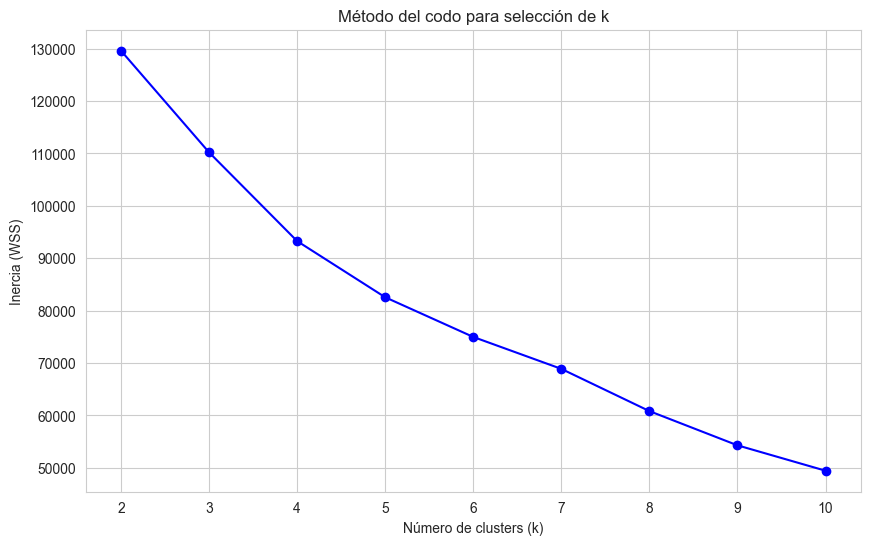

In [4]:
wss = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)

# Gráfico del codo
plt.plot(K_range, wss, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (WSS)')
plt.title('Método del codo para selección de k')
plt.xticks(K_range)
plt.grid(True)
plt.show()

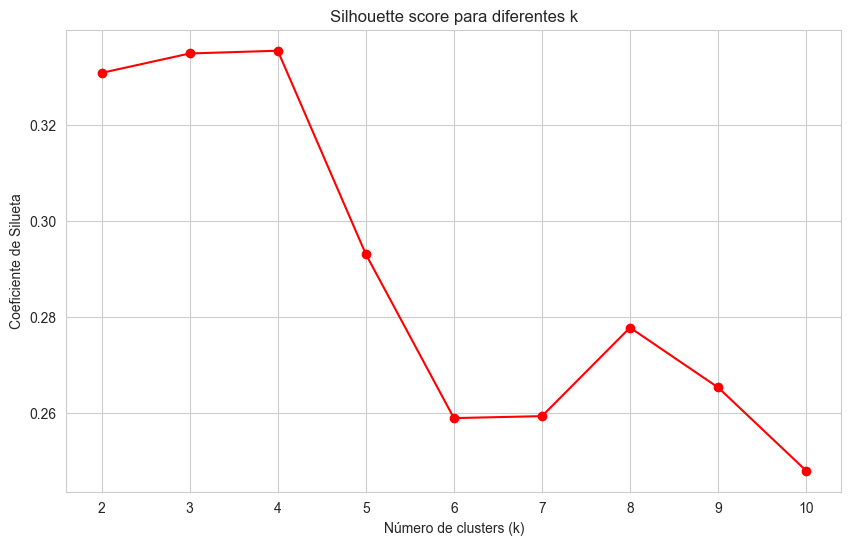

Mejor k según silueta: 4 (score = 0.335)


In [5]:
silhouette_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente de Silueta')
plt.title('Silhouette score para diferentes k')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Mostrar mejores valores
best_k_sil = K_range[np.argmax(silhouette_scores)]
print(f"Mejor k según silueta: {best_k_sil} (score = {max(silhouette_scores):.3f})")

In [7]:
k_clusters = 4
print(f"Usaremos k = {k_clusters} clusters")
# Aplicar K-means
kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
X['Cluster'] = cluster_labels
y_df = pd.Series(y, name='MedHouseVal')
data_with_cluster = pd.concat([X, y_df], axis=1)

# Ver distribución de clusters
print("Tamaño de cada cluster:")
print(data_with_cluster['Cluster'].value_counts().sort_index())

Usaremos k = 4 clusters
Tamaño de cada cluster:
Cluster
0     8627
1    11935
2        3
3       75
Name: count, dtype: int64


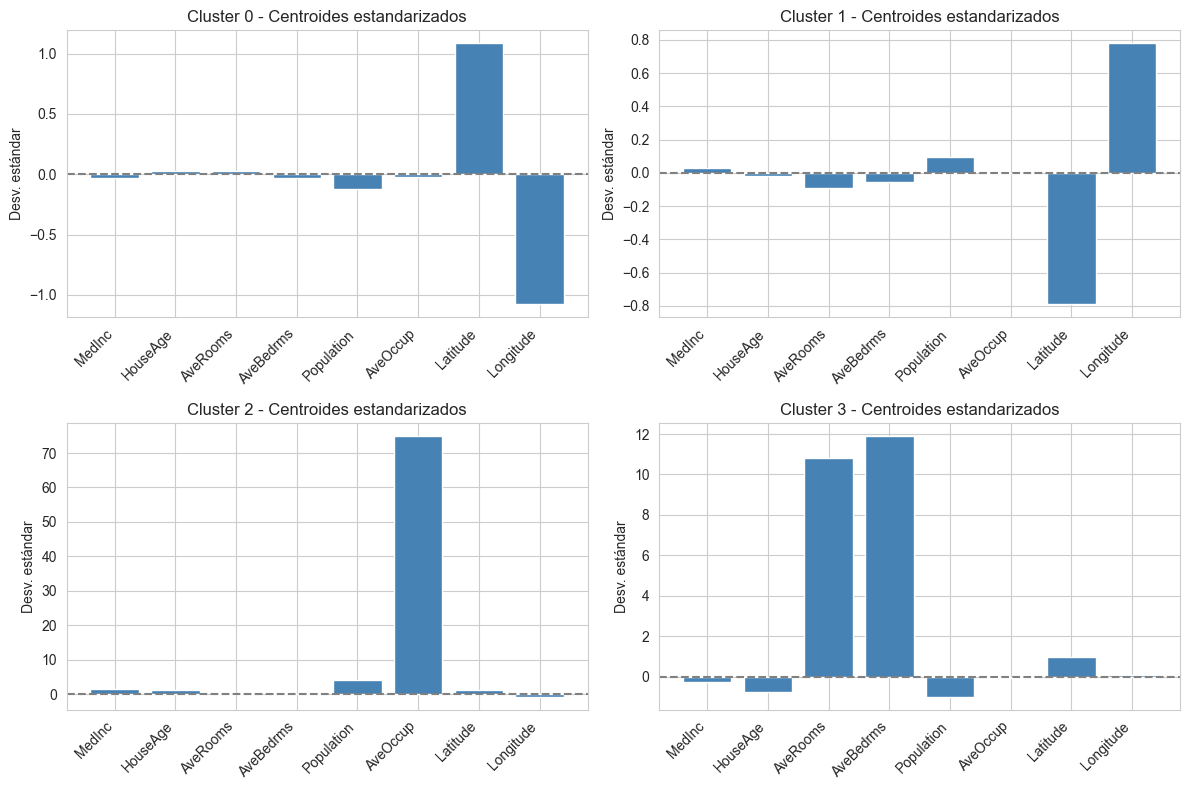

In [9]:
# Agrupar por cluster y calcular medias de las características originales
cluster_summary = data_with_cluster.groupby('Cluster').mean()
cluster_summary

# Visualización de perfiles (variables estandarizadas)
cluster_centers_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=housing.feature_names)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i in range(k_clusters):
    centers = cluster_centers_scaled.iloc[i]
    axes[i].bar(centers.index, centers.values, color='steelblue')
    axes[i].set_title(f'Cluster {i} - Centroides estandarizados')
    axes[i].set_xticklabels(centers.index, rotation=45, ha='right')
    axes[i].axhline(y=0, color='gray', linestyle='--')
    axes[i].set_ylabel('Desv. estándar')
plt.tight_layout()
plt.show()

In [11]:
# Dividir en entrenamiento (80%) y prueba (20%)
X_scaled_df = pd.DataFrame(X_scaled, columns=housing.feature_names)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)

# Re-aplicar K-means solo en entrenamiento
kmeans_train = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
cluster_train_labels = kmeans_train.fit_predict(X_train)

# Obtener los centroides de entrenamiento
centroids_train = kmeans_train.cluster_centers_

# Función para asignar cluster a un conjunto de datos
def assign_cluster(X_data, centroids):
    distances = np.linalg.norm(X_data.values[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

# Asignar clusters al conjunto de prueba
cluster_test_labels = assign_cluster(X_test, centroids_train)

print("Distribución de clusters en entrenamiento:")
print(pd.Series(cluster_train_labels).value_counts().sort_index())
print("\nDistribución de clusters en prueba (asignados):")
print(pd.Series(cluster_test_labels).value_counts().sort_index())

Distribución de clusters en entrenamiento:
0      66
1    9510
2    6933
3       3
Name: count, dtype: int64

Distribución de clusters en prueba (asignados):
0      15
1    2422
2    1691
Name: count, dtype: int64


In [12]:
knn_global = KNeighborsRegressor(n_neighbors=5)
knn_global.fit(X_train, y_train)
y_pred_global = knn_global.predict(X_test)

# Métricas globales
mae_global = mean_absolute_error(y_test, y_pred_global)
rmse_global = np.sqrt(mean_squared_error(y_test, y_pred_global))
r2_global = r2_score(y_test, y_pred_global)

print("=== Modelo GLOBAL ===")
print(f"MAE:  {mae_global:.4f}")
print(f"RMSE: {rmse_global:.4f}")
print(f"R²:   {r2_global:.4f}")

=== Modelo GLOBAL ===
MAE:  0.4455
RMSE: 0.6586
R²:   0.6690


In [13]:
# Entrenar un KNN por cada cluster usando SOLO los puntos de entrenamiento de ese cluster
knn_per_cluster = {}
for cluster_id in range(k_clusters):
    mask_train = (cluster_train_labels == cluster_id)
    if mask_train.sum() == 0:
        print(f"Cluster {cluster_id} no tiene datos de entrenamiento. Se usará el modelo global para ese cluster.")
        # Fallback: usar el mismo modelo global para ese cluster
        knn_per_cluster[cluster_id] = knn_global
    else:
        X_train_cluster = X_train[mask_train]
        y_train_cluster = y_train[mask_train]
        knn_local = KNeighborsRegressor(n_neighbors=5)
        knn_local.fit(X_train_cluster, y_train_cluster)
        knn_per_cluster[cluster_id] = knn_local

# Predecir en prueba usando el modelo correspondiente al cluster asignado a cada punto
y_pred_cluster = np.zeros_like(y_test)
for i, cluster_id in enumerate(cluster_test_labels):
    y_pred_cluster[i] = knn_per_cluster[cluster_id].predict([X_test.iloc[i].values])[0]

# Métricas por cluster
mae_cluster = mean_absolute_error(y_test, y_pred_cluster)
rmse_cluster = np.sqrt(mean_squared_error(y_test, y_pred_cluster))
r2_cluster = r2_score(y_test, y_pred_cluster)

print("\n=== Modelo por CLUSTER ===")
print(f"MAE:  {mae_cluster:.4f}")
print(f"RMSE: {rmse_cluster:.4f}")
print(f"R²:   {r2_cluster:.4f}")


=== Modelo por CLUSTER ===
MAE:  0.4457
RMSE: 0.6586
R²:   0.6690


In [14]:
# Comparar errores dentro de cada cluster por separado
print("\n--- Desglose por cluster ---")
for cluster_id in range(k_clusters):
    mask_test_cluster = (cluster_test_labels == cluster_id)
    if mask_test_cluster.sum() > 0:
        y_true_cl = y_test[mask_test_cluster]
        y_pred_global_cl = y_pred_global[mask_test_cluster]
        y_pred_cluster_cl = y_pred_cluster[mask_test_cluster]
        
        mae_global_cl = mean_absolute_error(y_true_cl, y_pred_global_cl)
        mae_cluster_cl = mean_absolute_error(y_true_cl, y_pred_cluster_cl)
        
        print(f"\nCluster {cluster_id} (n={mask_test_cluster.sum()} puntos):")
        print(f"  MAE global:  {mae_global_cl:.4f}")
        print(f"  MAE por cluster: {mae_cluster_cl:.4f}")
        print(f"  Mejora: {(mae_global_cl - mae_cluster_cl)/mae_global_cl*100:.1f}%")


--- Desglose por cluster ---

Cluster 0 (n=15 puntos):
  MAE global:  0.5058
  MAE por cluster: 0.4980
  Mejora: 1.5%

Cluster 1 (n=2422 puntos):
  MAE global:  0.4695
  MAE por cluster: 0.4697
  Mejora: -0.0%

Cluster 2 (n=1691 puntos):
  MAE global:  0.4106
  MAE por cluster: 0.4109
  Mejora: -0.1%


In [15]:
comparison = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Global': [mae_global, rmse_global, r2_global],
    'Por Cluster': [mae_cluster, rmse_cluster, r2_cluster],
    'Mejora (%)': [
        (mae_global - mae_cluster)/mae_global*100,
        (rmse_global - rmse_cluster)/rmse_global*100,
        (r2_cluster - r2_global)/abs(r2_global)*100
    ]
})
comparison

,Métrica,Global,Por Cluster,Mejora (%)
0,MAE,0.445525,0.445710,-0.041476
1,RMSE,0.658643,0.658588,0.008426
2,R²,0.668950,0.669006,0.008339
